##ЛР1. Pandas, EDA, линейная регрессия

[8 + 5 бонусных баллов]

## О формате сдачи (все ЛР)

🔷 **<font color='plum'>При решении используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, могут помечаться фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличие работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, могут помечаться фразами "Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Выводы подразумевают текстовый (письменный, не устный) ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

🔷 **<font color='plum'>Устная защита</font>**

    ❌❌❌ Если не пройдена устная защита по ЛР, то баллы не начисляются вовсе
    (вопросы устной защиты охватывают лекционный материал и практический материал по заданиям ЛР, список вопросов не публикуется)

## Этапы

<font color='DarkOrange'>**Задание 1 [баллов: 4]:**</font>

Выберите датасет и задачу для него (регрессия) - с Kaggle или UCI Machine Learning Repository (https://archive.ics.uci.edu/datasets).
Важно: используйте более новые датасеты, кол-во объектов не менее 100

Выполните EDA.
Придумайте вопросы к данным, которые потребуют использования следующих инструментов (напишите каждый вопрос и код к нему) [<font color='DarkOrange'>0,5 балла за покрытие каждого пункта</font>]:
- группировка с агрегацией (groupby),
- изменение дискретности по времени (resample),
- объединение датафреймов (merge,join или concat),
- статическая визуализация seaborn,
- интерактивный график plotly,
- визуализация распределений (гистограмма относительных частот, kde, boxplot, violinplot, scatter),
- тесты на свойства распределения (например, нормальность),
- One Hot Encoding для категориальных признаков (если их нет, то придумайте как некие классы, определяемые по другим числовым признакам)  

**Выполнил:** Данилов Тимофей, P3331

**Датасет:** [Real Estate Listings in Portugal](https://www.kaggle.com/datasets/luvathoms/portugal-real-estate-2024) (Kaggle, автор luvathoms).
Объявления о продаже недвижимости с португальских сайтов, автор обновляет выгрузку еженедельно; здесь версия от 25.09.2026, ~183 тыс. строк.

**Задача регрессии:** предсказать цену квартиры `Price` (евро) по её характеристикам — площади, числу санузлов, году постройки, району и т.д.

In [1]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from scipy import stats

pio.renderers.default = 'notebook_connected'
sns.set(style='darkgrid')
plt.rcParams['figure.figsize'] = [12, 5]
pd.set_option('display.max_columns', 30, 'display.width', 200)
RANDOM_STATE = 42

### 0. Загрузка, первичная очистка и отложенная выборка

Сначала только то, что не требует «подглядывать» в распределения:
приведение типов, удаление полных дубликатов и строк без цены.
Сразу после этого **откладываю 20% данных в тест** и дальше весь EDA (задание 1) и обучение (задание 2) делаю только на обучающей части.
Иначе решения, принятые по картинкам (пороги выбросов, выбор признаков), «видели» бы тест — это утечка (data leakage).

In [2]:
raw = pd.read_csv('data/portugal_listinigs.csv', low_memory=False)
print(raw.shape)
raw.head()

(182819, 23)


,Price,District,City,Town,Type,EnergyCertificate,Floor,NumberOfBathrooms,Parking,TotalArea,ConstructionYear,EnergyEfficiencyLevel,PublishDate,Garage,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea
0,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,1st Floor,0.0,1.0,114.0,NaN,NaN,NaN,NaN,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN
1,158000.0,Faro,Portimão,Portimão,Apartment,D,2nd Floor,2.0,1.0,21953.0,1993.0,NaN,NaN,NaN,True,NaN,1.0,NaN,NaN,NaN,42.0,NaN,48.0
2,19000.0,Faro,Lagoa (Algarve),Estômbar e Parchal,Land,NC,NaN,0.0,0.0,3710.0,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,3710.0,NaN,3710.0
3,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,1st Floor,2.0,1.0,115.0,NaN,NaN,NaN,NaN,True,NaN,2.0,NaN,NaN,NaN,115.0,NaN,NaN
4,2950000.0,Faro,Albufeira,Albufeira e Olhos de Água,Building,NC,NaN,0.0,0.0,265.0,1998.0,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,406.0,NaN,465.0


In [3]:
# типы и доля пропусков по столбцам
pd.DataFrame({'dtype': raw.dtypes.astype(str),
              'пропуски, %': (raw.isna().mean() * 100).round(1),
              'уникальных': raw.nunique()})

,dtype,"пропуски, %",уникальных
Price,float64,0.2,6221
District,str,0.0,28
City,str,0.0,281
Town,str,0.0,2340
Type,str,0.0,21
EnergyCertificate,str,0.0,12
Floor,str,84.7,19
NumberOfBathrooms,float64,9.4,50
Parking,float64,0.0,4
TotalArea,float64,8.4,7611


In [4]:
df = raw.copy()
df['PublishDate'] = pd.to_datetime(df['PublishDate'], errors='coerce')
for col in ['Garage', 'Elevator', 'ElectricCarsCharging']:
    # в CSV эти столбцы — строки 'True'/'False' вперемешку с bool
    df[col] = df[col].map({True: 1.0, False: 0.0, 'True': 1.0, 'False': 0.0})

n0 = len(df)
df = df.drop_duplicates()
n_dup = n0 - len(df)
df = df[df['Price'].notna()]
print(f'полных дубликатов удалено: {n_dup}, строк без цены удалено: {n0 - n_dup - len(df)}, осталось: {len(df)}')

полных дубликатов удалено: 11003, строк без цены удалено: 436, осталось: 171380


In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
print('train:', train_df.shape, ' test:', test_df.shape)
# test_df не трогаем до финальной оценки моделей в задании 2

train: (137104, 23)  test: (34276, 23)


Общая картина по обучающей части: какие типы объектов есть и сколько у них пропусков в ключевых столбцах.

In [6]:
train_df['Type'].value_counts().head(10)

Type
Apartment             50023
House                 37552
Land                  30204
Store                  5158
Farm                   3790
Building               2531
Transfer of lease      1825
Warehouse              1424
Garage                  965
Other - Commercial      777
Name: count, dtype: int64

In [7]:
train_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Price,137104.0,397579.261577,1.0,95000.0,235000.0,420000.0,2000000000.0,5440403.733984
NumberOfBathrooms,123918.0,1.698188,-13.0,0.0,1.0,2.0,3020.0,8.743653
Parking,137080.0,0.490765,0.0,0.0,0.0,1.0,3.0,0.76623
TotalArea,125600.0,516997.300279,-7196067.0,88.0,142.0,360.0,61420071105.0,173354717.391306
ConstructionYear,91529.0,1989.763823,1900.0,1973.0,1994.0,2009.0,2026.0,26.838323
PublishDate,57442,2025-08-11 11:38:04.310733,2018-04-09 05:48:21.907000,2024-11-06 16:46:14.647000,2025-10-28 14:11:48.430000,2026-05-29 15:11:00.293500,2026-09-24 20:32:32.047000,NaN
Garage,86014.0,0.182714,0.0,0.0,0.0,0.0,1.0,0.386434
Elevator,137080.0,0.250438,0.0,0.0,0.0,1.0,1.0,0.433267
ElectricCarsCharging,86014.0,0.128061,0.0,0.0,0.0,0.0,1.0,0.334159
TotalRooms,67104.0,3.398814,0.0,2.0,3.0,4.0,100.0,2.826353


Уже видно, что данные «грязные»: отрицательные площади и число санузлов, площадь 6·10¹⁰ м², цена от 1 € до 2 млрд €.
Это ошибки ввода на сайтах объявлений — с ними разберусь при подготовке данных к модели (задание 2).
Для EDA считаю цену за м² только по жилым объектам с правдоподобной жилой площадью (10–1000 м²).

In [8]:
eda = train_df.copy()
ok_area = eda['LivingArea'].between(10, 1000)
eda['PricePerM2'] = np.where(ok_area, eda['Price'] / eda['LivingArea'], np.nan)
apt = eda[(eda['Type'] == 'Apartment') & ok_area & eda['Price'].between(10_000, 20_000_000)].copy()
apt['EnergyCertificate'] = apt['EnergyCertificate'].replace({'No Certificate': 'NC', 'Not available': 'NC'})
print('квартир с корректной площадью и ценой:', len(apt))

квартир с корректной площадью и ценой: 49416


#### Вопрос 1 (groupby + агрегация). Какие типы недвижимости и какие округа самые дорогие за квадратный метр?

In [9]:
by_type = (eda.groupby('Type')
              .agg(n=('Price', 'size'),
                   median_price=('Price', 'median'),
                   median_price_m2=('PricePerM2', 'median'))
              .query('n >= 300')
              .sort_values('median_price', ascending=False))
by_type.round(0)

,n,median_price,median_price_m2
Type,,,
Duplex,417,555000.0,4148.0
Building,2531,550000.0,2115.0
Industrial,382,499600.0,875.0
Warehouse,1424,299950.0,747.0
Apartment,50023,299000.0,3550.0
Farm,3790,295000.0,2021.0
House,37552,275000.0,1782.0
Other - Commercial,777,235000.0,1500.0
Office,676,210000.0,2500.0


In [10]:
by_district = (apt.groupby('District')
                  .agg(n=('Price', 'size'),
                       median_price=('Price', 'median'),
                       median_price_m2=('PricePerM2', 'median'),
                       median_area=('LivingArea', 'median'))
                  .query('n >= 50')
                  .sort_values('median_price_m2', ascending=False))
by_district.round(0)

,n,median_price,median_price_m2,median_area
District,,,,
Lisboa,18066,380000.0,4633.0,89.0
Faro,3748,348250.0,3955.0,89.0
Porto,10965,305900.0,3667.0,92.0
Setúbal,5476,275000.0,3214.0,86.0
Aveiro,1958,262500.0,2798.0,99.0
Coimbra,1987,247500.0,2685.0,98.0
Viana do Castelo,649,215000.0,2604.0,96.0
Leiria,1429,245000.0,2398.0,103.0
Braga,2759,236500.0,2283.0,110.0


**Ответ.** TODO_Q1

#### Вопрос 2 (resample). Как по месяцам меняются число новых объявлений о квартирах и медианная цена м²?

Дата публикации есть не у всех объявлений (см. пропуски выше), поэтому берём только строки с `PublishDate`.

In [11]:
monthly = (apt.dropna(subset=['PublishDate'])
              .set_index('PublishDate')
              .sort_index()
              .loc['2024-01-01':]
              .resample('MS')
              .agg({'Price': 'size', 'PricePerM2': 'median'})
              .rename(columns={'Price': 'listings', 'PricePerM2': 'median_price_m2'}))
monthly.tail(12)

,listings,median_price_m2
PublishDate,,
2025-10-01,333,4350.000000
2025-11-01,488,4656.862745
2025-12-01,392,4438.100962
2026-01-01,529,4166.666667
2026-02-01,581,4217.592593
2026-03-01,1232,4432.855951
2026-04-01,1191,4071.428571
2026-05-01,1326,3828.428094
2026-06-01,1897,4404.605263


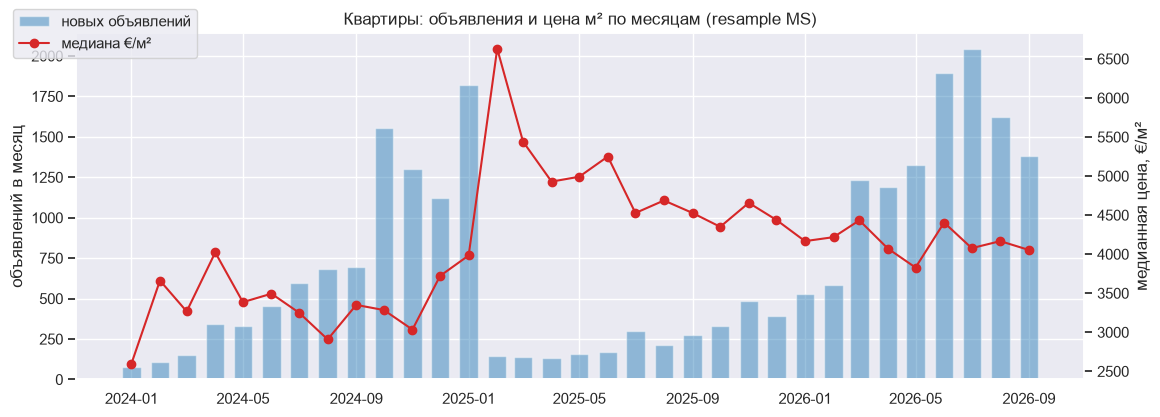

In [12]:
fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.bar(monthly.index, monthly['listings'], width=20, color='tab:blue', alpha=0.45, label='новых объявлений')
ax1.set_ylabel('объявлений в месяц')
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['median_price_m2'], color='tab:red', marker='o', label='медиана €/м²')
ax2.set_ylabel('медианная цена, €/м²')
ax2.grid(False)
fig.legend(loc='upper left', bbox_to_anchor=(0.07, 0.95))
ax1.set_title('Квартиры: объявления и цена м² по месяцам (resample MS)')
plt.show()

**Ответ.** TODO_Q2

#### Вопрос 3 (merge). Как отличаются цены в крупных регионах Португалии?

В данных есть только округ (`District`). Регион беру из собственной справочной таблицы: округ → укрупнённый регион
(по преобладающему региону NUTS II; границы NUTS II не совпадают с границами округов, так что это приближение —
например, часть округа Сетубал формально относится к Алентежу).
Справочник присоединяю через `merge` и проверяю, что все округа нашлись.

In [13]:
regions = pd.DataFrame({
    'District': ['Viana do Castelo', 'Braga', 'Porto', 'Vila Real', 'Bragança',
                 'Aveiro', 'Viseu', 'Guarda', 'Coimbra', 'Castelo Branco', 'Leiria', 'Santarém',
                 'Lisboa', 'Setúbal',
                 'Portalegre', 'Évora', 'Beja',
                 'Faro',
                 'Ilha da Madeira', 'Ilha de Porto Santo',
                 'Ilha de São Miguel', 'Ilha Terceira', 'Ilha de Santa Maria', 'Ilha do Faial',
                 'Ilha do Pico', 'Ilha de São Jorge', 'Ilha das Flores'],
    'Region': ['Norte'] * 5 + ['Centro'] * 7 + ['Lisboa (AML)'] * 2 + ['Alentejo'] * 3 + ['Algarve']
              + ['Madeira'] * 2 + ['Açores'] * 7,
})
regions['Coastal'] = ~regions['District'].isin(['Vila Real', 'Bragança', 'Viseu', 'Guarda', 'Castelo Branco',
                                                  'Santarém', 'Portalegre', 'Évora', 'Beja'])

apt = apt.merge(regions, on='District', how='left', indicator=True)
print(apt['_merge'].value_counts())
print('не нашлись:', apt.loc[apt['_merge'] != 'both', 'District'].unique())
apt = apt.drop(columns='_merge')

_merge
both          49415
left_only         1
right_only        0
Name: count, dtype: int64
не нашлись: <StringArray>
['Z - Fora de Portugal']
Length: 1, dtype: str


In [14]:
(apt.groupby('Region')
    .agg(n=('Price', 'size'), median_price=('Price', 'median'), median_price_m2=('PricePerM2', 'median'))
    .sort_values('median_price_m2', ascending=False)
    .round(0))

,n,median_price,median_price_m2
Region,,,
Lisboa (AML),23542,350000.0,4250.0
Algarve,3748,348250.0,3955.0
Açores,7,295000.0,3315.0
Norte,14698,282000.0,3162.0
Madeira,2,235000.0,3128.0
Centro,6932,230000.0,2393.0
Alentejo,486,160000.0,1565.0


In [15]:
apt.groupby('Coastal')['PricePerM2'].median().rename({True: 'побережье', False: 'внутренние округа'}).round(0)

Coastal
внутренние округа    1667.0
побережье            3686.0
Name: PricePerM2, dtype: float64

**Ответ.** TODO_Q3

#### Вопрос 4 (статическая визуализация seaborn). Дороже ли м² в квартирах с лучшим энергетическим сертификатом? Какие числовые признаки связаны с ценой?

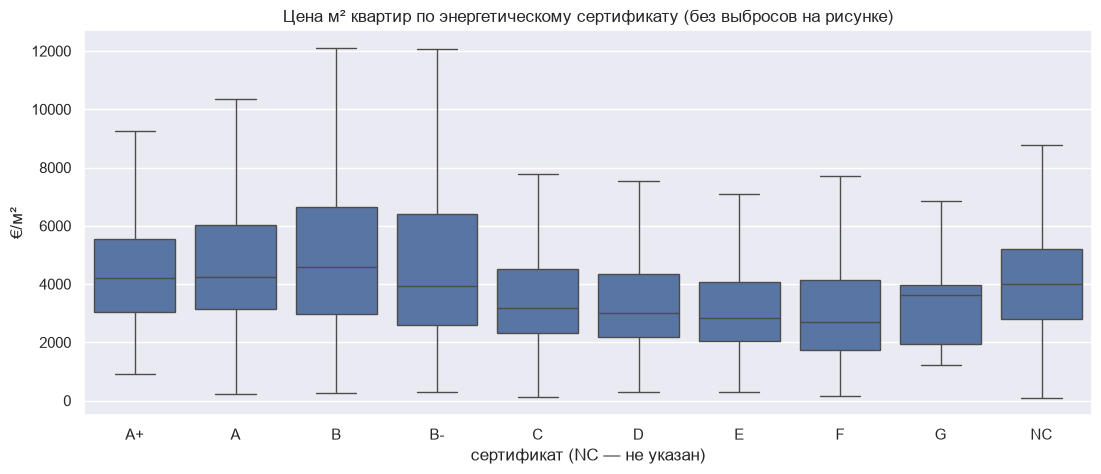

EnergyCertificate,A+,A,B,B-,C,D,E,F,G,NC
size,3195.0,7752.0,2237.0,2094.0,9800.0,9434.0,4552.0,1359.0,47.0,8946.0
median,4207.0,4252.0,4578.0,3937.0,3182.0,3000.0,2829.0,2688.0,3611.0,4000.0


In [16]:
cert_order = ['A+', 'A', 'B', 'B-', 'C', 'D', 'E', 'F', 'G', 'NC']
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=apt[apt['EnergyCertificate'].isin(cert_order)], x='EnergyCertificate', y='PricePerM2',
            order=cert_order, showfliers=False, ax=ax)
ax.set(title='Цена м² квартир по энергетическому сертификату (без выбросов на рисунке)',
       xlabel='сертификат (NC — не указан)', ylabel='€/м²')
plt.show()
apt.groupby('EnergyCertificate')['PricePerM2'].agg(['size', 'median']).reindex(cert_order).round(0).T

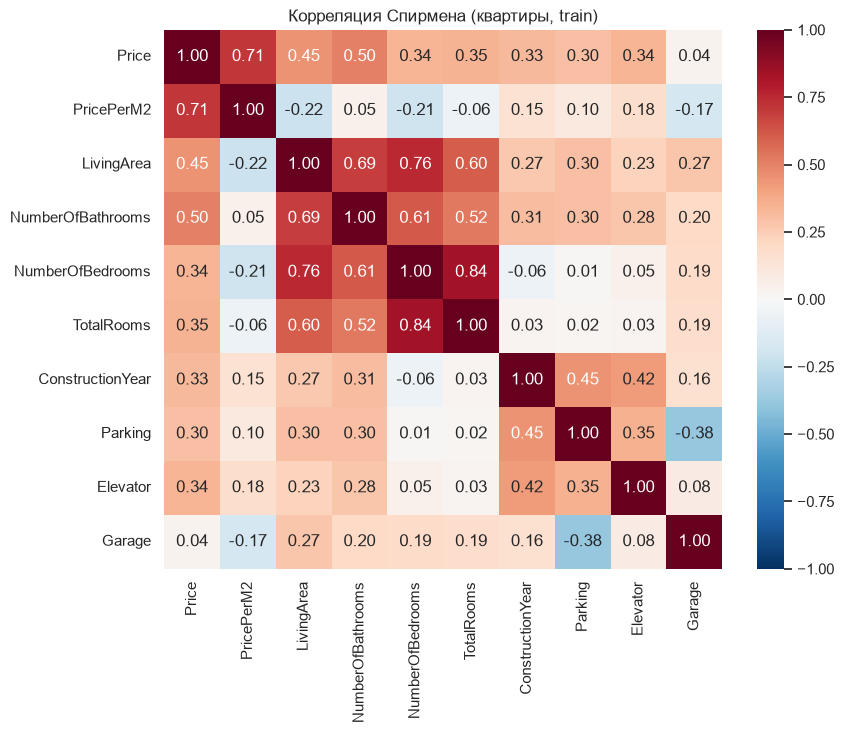

In [17]:
num_cols = ['Price', 'PricePerM2', 'LivingArea', 'NumberOfBathrooms', 'NumberOfBedrooms',
            'TotalRooms', 'ConstructionYear', 'Parking', 'Elevator', 'Garage']
corr = apt[num_cols].corr(method='spearman')
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Корреляция Спирмена (квартиры, train)')
plt.show()

**Ответ.** TODO_Q4

#### Вопрос 5 (интерактивный график plotly). Как цена квартиры связана с площадью в разных регионах?

Наведите курсор на точку — видны город, год постройки и цена м². Клик по региону в легенде скрывает/показывает его.
Для скорости — случайная подвыборка 5000 квартир; оси логарифмические.

In [18]:
sample = apt.sample(5000, random_state=RANDOM_STATE)
fig = px.scatter(sample, x='LivingArea', y='Price', color='Region', log_x=True, log_y=True, opacity=0.55,
                 hover_data={'City': True, 'ConstructionYear': True, 'PricePerM2': ':.0f', 'Region': False},
                 labels={'LivingArea': 'жилая площадь, м²', 'Price': 'цена, €'},
                 title='Квартиры: цена vs площадь (log-log), 5000 случайных объявлений')
fig.update_layout(height=550)
fig.show()

**Ответ.** TODO_Q5

#### Вопрос 6 (визуализация распределений). Как распределены цена квартиры и цена м²?

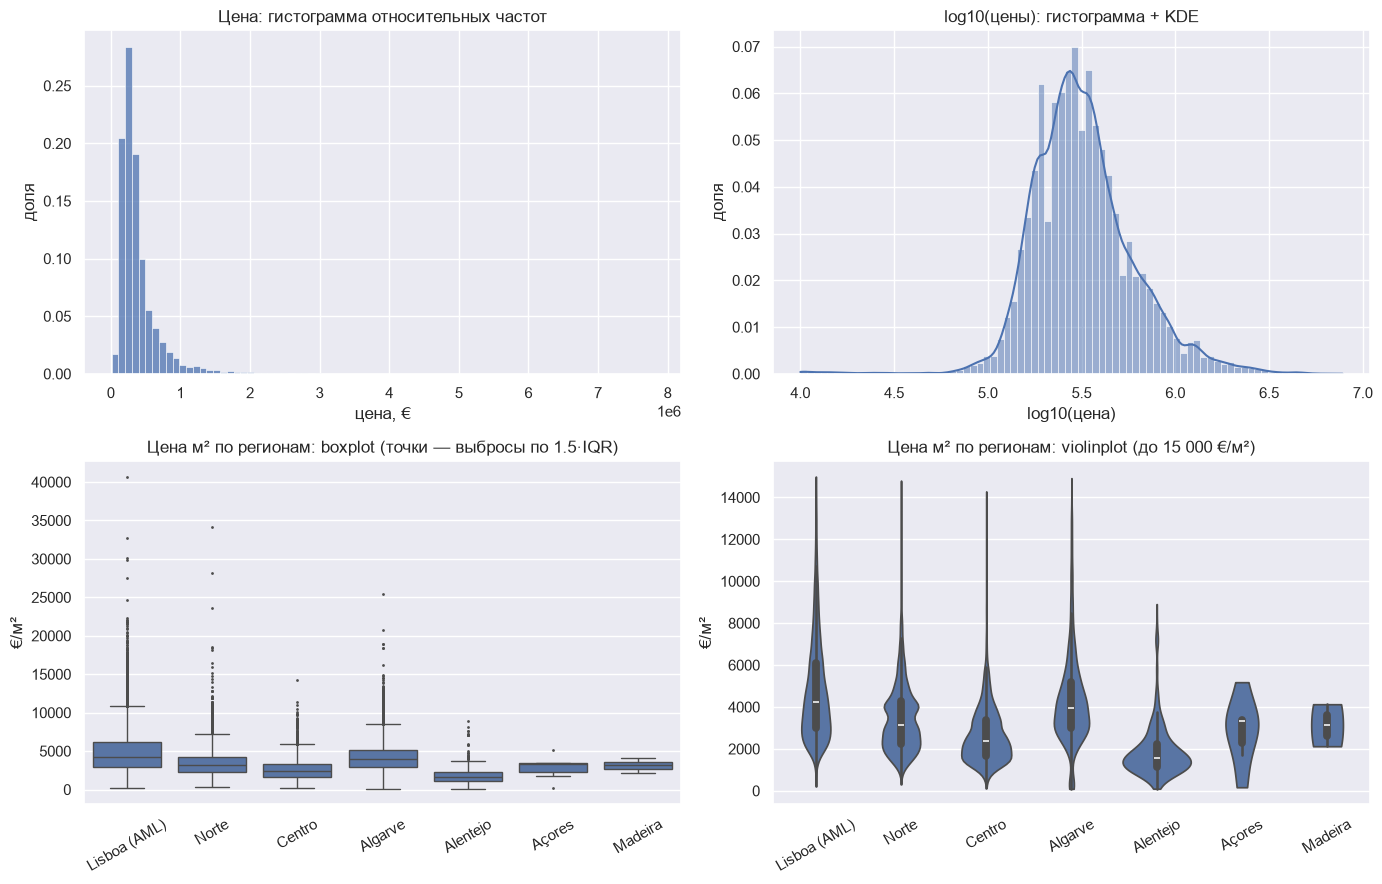

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(apt['Price'], bins=80, stat='probability', ax=axes[0, 0])
axes[0, 0].set(title='Цена: гистограмма относительных частот', xlabel='цена, €', ylabel='доля')
sns.histplot(np.log10(apt['Price']), bins=80, stat='probability', kde=True, ax=axes[0, 1])
axes[0, 1].set(title='log10(цены): гистограмма + KDE', xlabel='log10(цена)', ylabel='доля')
sns.boxplot(data=apt, x='Region', y='PricePerM2', showfliers=True, ax=axes[1, 0], fliersize=1)
axes[1, 0].set(title='Цена м² по регионам: boxplot (точки — выбросы по 1.5·IQR)', xlabel='', ylabel='€/м²')
axes[1, 0].tick_params(axis='x', rotation=30)
sns.violinplot(data=apt[apt['PricePerM2'] < 15000], x='Region', y='PricePerM2', cut=0, ax=axes[1, 1])
axes[1, 1].set(title='Цена м² по регионам: violinplot (до 15 000 €/м²)', xlabel='', ylabel='€/м²')
axes[1, 1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

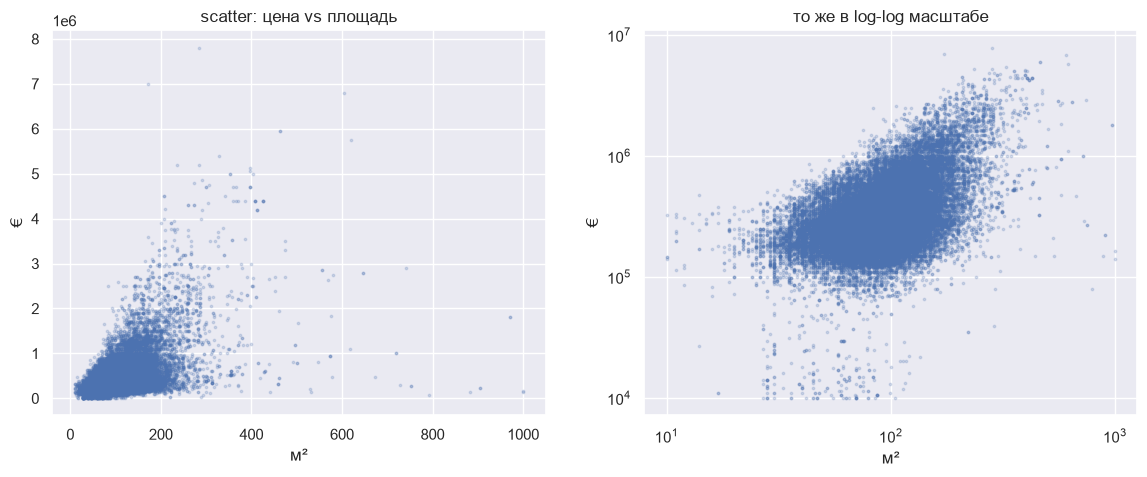

асимметрия цены: 4.89  асимметрия log(цены): 0.2


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(apt['LivingArea'], apt['Price'], s=3, alpha=0.2)
axes[0].set(title='scatter: цена vs площадь', xlabel='м²', ylabel='€')
axes[1].scatter(apt['LivingArea'], apt['Price'], s=3, alpha=0.2)
axes[1].set(xscale='log', yscale='log', title='то же в log-log масштабе', xlabel='м²', ylabel='€')
plt.show()
print('асимметрия цены:', round(apt['Price'].skew(), 2), ' асимметрия log(цены):', round(np.log(apt['Price']).skew(), 2))

**Ответ.** TODO_Q6

#### Вопрос 7 (тесты на свойства распределения). Можно ли считать нормальными цену квартиры и её логарифм?

H₀: выборка из нормального распределения. Проверяю тремя тестами:
Шапиро–Уилка (на подвыборке 5000 — у scipy тест корректен до n≈5000), Д'Агостино–Пирсона K² (по асимметрии и эксцессу) и Андерсона–Дарлинга.
Плюс Q-Q plot — на больших выборках тесты отвергают H₀ даже при мелких отклонениях, поэтому важно и посмотреть глазами.

In [21]:
def normality_report(x, name):
    x = np.asarray(x.dropna())
    sub = np.random.default_rng(RANDOM_STATE).choice(x, size=min(5000, len(x)), replace=False)
    sw = stats.shapiro(sub)
    k2 = stats.normaltest(x)
    ad = stats.anderson(x, dist='norm')
    crit5 = ad.critical_values[list(ad.significance_level).index(5.0)]
    return {'признак': name, 'n': len(x), 'асимметрия': stats.skew(x), 'эксцесс': stats.kurtosis(x),
            'Shapiro p (n=5000)': sw.pvalue, "D'Agostino p": k2.pvalue,
            'Anderson A²': ad.statistic, 'A² крит. 5%': crit5}

norm_tbl = pd.DataFrame([normality_report(apt['Price'], 'Price'),
                         normality_report(np.log(apt['Price']), 'log(Price)'),
                         normality_report(np.log(apt['PricePerM2']), 'log(PricePerM2)')])
norm_tbl.round(4)

,признак,n,асимметрия,эксцесс,Shapiro p (n=5000),D'Agostino p,Anderson A²,A² крит. 5%
0,Price,49416,4.8890,41.7734,0.0,0.0,4504.6591,0.752
1,log(Price),49416,0.2032,2.7974,0.0,0.0,364.0554,0.752
2,log(PricePerM2),49416,-0.3714,1.7433,0.0,0.0,30.9837,0.752


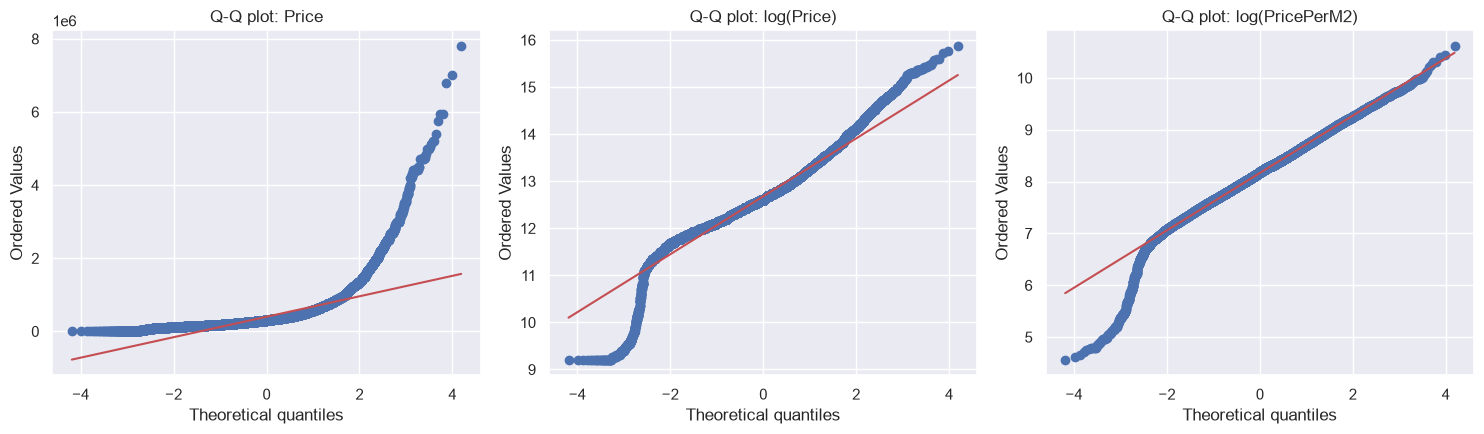

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, x) in zip(axes, [('Price', apt['Price']), ('log(Price)', np.log(apt['Price'])),
                                ('log(PricePerM2)', np.log(apt['PricePerM2']))]):
    stats.probplot(x, dist='norm', plot=ax)
    ax.set_title(f'Q-Q plot: {name}')
plt.tight_layout()
plt.show()

**Ответ.** TODO_Q7

#### Вопрос 8 (One Hot Encoding). Какие значения категориальных признаков сильнее всего связаны с ценой м²?

`EnergyCertificate` и `Region` — номинальные категории (у сертификата есть порядок A+…G, но значение `NC` «не указан» в этот порядок не вписывается),
поэтому кодирую их one-hot: каждая категория — отдельный столбец 0/1. Затем считаю корреляцию каждого столбца с log(цены м²).

In [23]:
ohe = pd.get_dummies(apt[['EnergyCertificate', 'Region']], prefix=['cert', 'reg'], dtype=int)
print(ohe.shape)
ohe.head()

(49416, 17)


,cert_A,cert_A+,cert_B,cert_B-,cert_C,cert_D,cert_E,cert_F,cert_G,cert_NC,reg_Alentejo,reg_Algarve,reg_Açores,reg_Centro,reg_Lisboa (AML),reg_Madeira,reg_Norte
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0


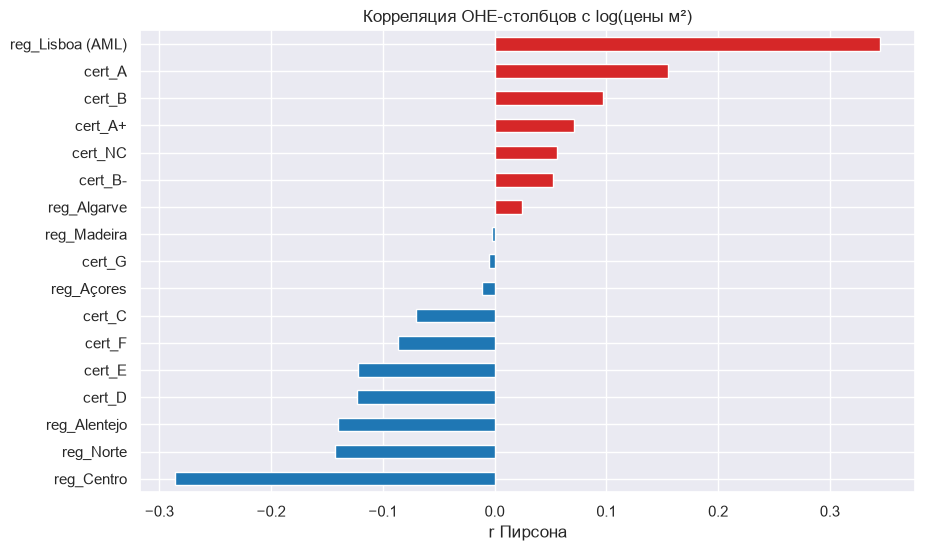

In [24]:
ohe_corr = ohe.corrwith(np.log(apt['PricePerM2'])).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ohe_corr.plot.barh(ax=ax, color=np.where(ohe_corr > 0, 'tab:red', 'tab:blue'))
ax.set(title='Корреляция OHE-столбцов с log(цены м²)', xlabel='r Пирсона')
plt.show()

**Ответ.** TODO_Q8

### Итоги EDA
TODO_EDA

<font color='DarkOrange'>**Задание 2 [баллов: 4]:**</font>

1.Выберите один из признаков как таргет (регрессант, предиктант), также выберите некоторе число признаков в качестве регрессоров (предикторов). Обоснуйте, что эти признаки имеет смысл использовать как регрессоры, исходя из предметной области (природы датасета), проведите аналитику - представьте код и рисунки. [<font color='DarkOrange'>1 балл</font>]

<font color='DarkOrange'>Важно! </font> Если выполняете исследование данных до разделения на обучающую, которая нужна для моделирования, и отложенную выборки (тестовую), то это потенциал для утечек (data leakage)! Следует сразу отделить часть данных, исследовать их только перед прогоном на уже обученной готовой модели!

2.Обучите линейную регрессионную модель без регуляризации. Проиллюстрируйте процесс обучения и тестирования модели, запишите выводы о качестве. Метрики: RMSE, MAE, $R^{2}$ [<font color='DarkOrange'>1 балл</font>]

3.Обучите линейную регрессионную модель с регуляризацией (любой). Для предобработки осуществите удаление выбросов и нормирование - запишите обоснование для выбора способа поиска выбросов и нормирования. Используйте для этапов Pipeline из sklearn. Проиллюстрируйте процесс обучения и тестирования модели, запишите выводы о качестве. Метрики: RMSE, MAE, $R^{2}$ [<font color='DarkOrange'>2 балла</font>]

### 2.1. Таргет, регрессоры и подготовка данных

**Таргет:** `Price` — цена квартиры, €. Беру только квартиры (`Type == 'Apartment'`): у земли, гаражей и складов совсем другое ценообразование, в одну линейную модель их смешивать нельзя.

**Регрессоры** и почему они должны влиять на цену (из предметной области):

| признак | тип | почему влияет на цену |
|---|---|---|
| `LivingArea` | число | цену квартиры по сути задают как «цена м² × площадь» — главный фактор |
| `NumberOfBathrooms` | число | больше санузлов — больше и дороже квартира, признак класса жилья |
| `ConstructionYear` | число | новостройки дороже старого фонда (кроме исторических центров) |
| `Parking` | число | машино-места — отдельный дорогой актив, особенно в Лиссабоне/Порту |
| `Elevator` | 0/1 | лифт — признак многоэтажного и более нового дома |
| `EnergyCertificate` | категория | класс A/A+ в Португалии фактически означает новостройку или капремонт |
| `District` | категория | «локация, локация, локация»: разница цены м² между округами — в разы (вопрос 1) |
| `City` | категория | муниципалитет внутри округа: Лиссабон/Кашкайш и Синтра в одном округе, но цены сильно разные. Редкие (< 30 объявлений в train) объединяются в одну категорию |

Не беру: `TotalArea` (в ней смешаны площадь участка и квартиры, ошибки на порядки), `NumberOfBedrooms`/`TotalRooms` (35% пропусков и сильно коррелируют с площадью),
`Floor` и `ConservationStatus` (65–77% пропусков), `Town` (2300 значений — слишком дробно, хватит муниципалитета `City`).

**Явные ошибки ввода** отсекаю фиксированными правилами — одинаково на train и test, пороги не подбираются по данным, поэтому утечки нет:
жилая площадь 10–1000 м², цена 10 000 – 20 000 000 € (квартира за 600 € — это аренда или опечатка),
отрицательное число санузлов/мест и год постройки вне 1900–2026 → пропуск (потом заполним медианой).

In [25]:
FEATURES_NUM = ['LivingArea', 'NumberOfBathrooms', 'ConstructionYear', 'Parking', 'Elevator']
FEATURES_CAT = ['EnergyCertificate', 'District', 'City']
FEATURES = FEATURES_NUM + FEATURES_CAT
TARGET = 'Price'

def prepare_apartments(d):
    d = d[(d['Type'] == 'Apartment')
          & d['LivingArea'].between(10, 1000)
          & d['Price'].between(10_000, 20_000_000)].copy()
    d.loc[~d['NumberOfBathrooms'].between(0, 10), 'NumberOfBathrooms'] = np.nan
    d.loc[~d['ConstructionYear'].between(1900, 2026), 'ConstructionYear'] = np.nan
    d.loc[d['EnergyCertificate'].isin(['No Certificate', 'Not available']), 'EnergyCertificate'] = 'NC'
    return d[FEATURES], d[TARGET]

X_train, y_train = prepare_apartments(train_df)
X_test, y_test = prepare_apartments(test_df)
print('train:', X_train.shape, ' test:', X_test.shape)
X_train.isna().mean().round(3)

train: (49416, 8)  test: (12299, 8)


LivingArea           0.000
NumberOfBathrooms    0.002
ConstructionYear     0.202
Parking              0.000
Elevator             0.000
EnergyCertificate    0.000
District             0.000
City                 0.000
dtype: float64

Аналитика связи регрессоров с таргетом — **только на train**.

Корреляция Спирмена с ценой:
NumberOfBathrooms    0.500
LivingArea           0.452
Elevator             0.337
ConstructionYear     0.325
Parking              0.304
Name: Price, dtype: float64


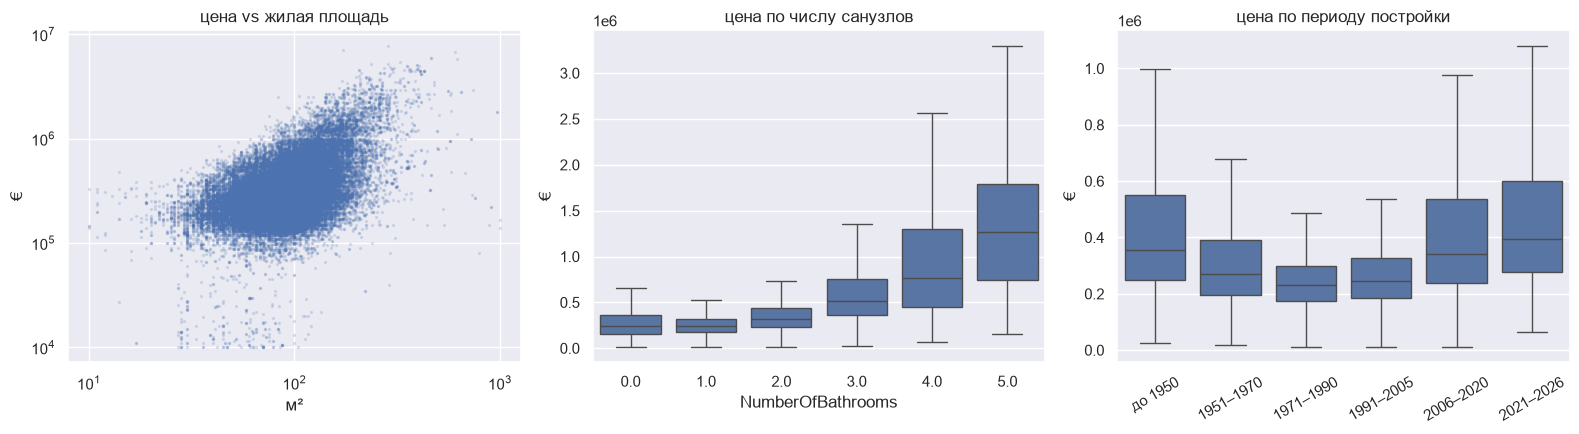

In [26]:
tr = X_train.assign(Price=y_train)
print('Корреляция Спирмена с ценой:')
print(tr[FEATURES_NUM + ['Price']].corr(method='spearman')['Price'].drop('Price').round(3).sort_values(ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(tr['LivingArea'], tr['Price'], s=2, alpha=0.15)
axes[0].set(xscale='log', yscale='log', title='цена vs жилая площадь', xlabel='м²', ylabel='€')
sns.boxplot(data=tr[tr['NumberOfBathrooms'] <= 5], x='NumberOfBathrooms', y='Price', showfliers=False, ax=axes[1])
axes[1].set(title='цена по числу санузлов', ylabel='€')
periods = ['до 1950', '1951–1970', '1971–1990', '1991–2005', '2006–2020', '2021–2026']
tr['period'] = pd.cut(tr['ConstructionYear'], [1899, 1950, 1970, 1990, 2005, 2020, 2026], labels=periods)
sns.boxplot(data=tr.dropna(subset=['period']), x='period', y='Price', order=periods, showfliers=False, ax=axes[2])
axes[2].set(title='цена по периоду постройки', xlabel='', ylabel='€')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

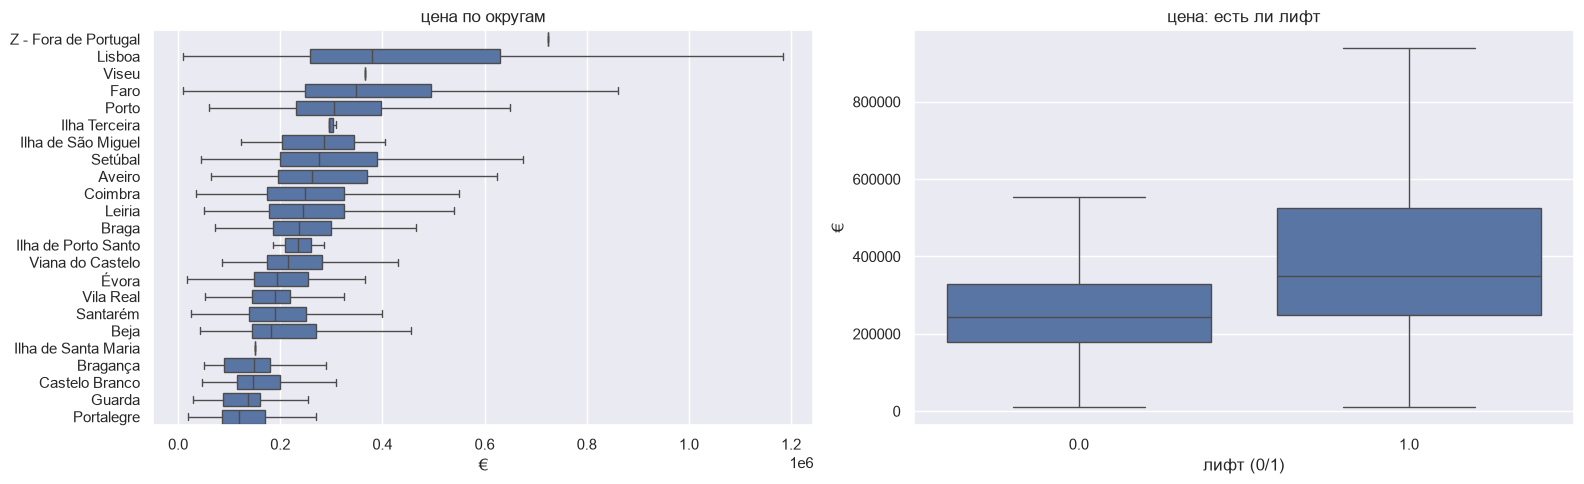

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
order = tr.groupby('District')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=tr, y='District', x='Price', order=order, showfliers=False, ax=axes[0])
axes[0].set(title='цена по округам', xlabel='€', ylabel='')
sns.boxplot(data=tr, x='Elevator', y='Price', showfliers=False, ax=axes[1])
axes[1].set(title='цена: есть ли лифт', xlabel='лифт (0/1)', ylabel='€')
plt.tight_layout()
plt.show()

**Вывод.** TODO_21

### 2.2. Линейная регрессия без регуляризации

Минимальная предобработка, без которой модель не обучится: пропуски в числах → медиана (+ столбец-индикатор пропуска),
пропуски в категориях → самое частое значение, категории → one-hot. Никакого удаления выбросов и нормирования — это будет в 2.3.
Модель — `LinearRegression` (МНК), таргет — цена в евро как есть.

In [28]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, cross_validate, learning_curve
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def metrics(y_true, y_pred):
    return {'RMSE': root_mean_squared_error(y_true, y_pred),
            'MAE': mean_absolute_error(y_true, y_pred),
            'R2': r2_score(y_true, y_pred)}

def evaluate(model, name):
    """CV на train, затем обучение на всём train и оценка на отложенном test."""
    cvr = cross_validate(model, X_train, y_train, cv=cv,
                         scoring={'RMSE': 'neg_root_mean_squared_error', 'MAE': 'neg_mean_absolute_error', 'R2': 'r2'})
    model.fit(X_train, y_train)
    rows = {
        'train': metrics(y_train, model.predict(X_train)),
        'CV (5 фолдов, среднее)': {'RMSE': -cvr['test_RMSE'].mean(), 'MAE': -cvr['test_MAE'].mean(), 'R2': cvr['test_R2'].mean()},
        'test': metrics(y_test, model.predict(X_test)),
    }
    return pd.DataFrame(rows).T.rename_axis(name)

def plot_fit(model, title):
    """Кривая обучения + прогноз vs факт на test + распределение остатков."""
    sizes, tr_sc, va_sc = learning_curve(model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error',
                                         train_sizes=np.linspace(0.05, 1.0, 8), shuffle=True, random_state=RANDOM_STATE)
    pred = model.predict(X_test)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    axes[0].plot(sizes, -tr_sc.mean(1), 'o-', label='train')
    axes[0].plot(sizes, -va_sc.mean(1), 'o-', label='валидация (CV)')
    axes[0].set(title='Кривая обучения', xlabel='объектов в обучении', ylabel='RMSE, €')
    axes[0].legend()
    lim = [1e4, 5e6]
    axes[1].scatter(y_test, np.clip(pred, 1e3, None), s=3, alpha=0.2)
    axes[1].plot(lim, lim, 'r--', lw=1)
    axes[1].set(xscale='log', yscale='log', xlim=lim, ylim=[1e3, 1e7],
                title='test: прогноз vs факт', xlabel='факт, €', ylabel='прогноз, €')
    resid = y_test - pred
    sns.histplot(resid.clip(-1e6, 1e6), bins=100, stat='probability', ax=axes[2])
    axes[2].set(title='test: остатки (факт − прогноз), обрезаны до ±1 млн', xlabel='€')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [29]:
def log_first_column(a):
    a = a.copy()
    a[:, 0] = np.log(a[:, 0])
    return a

def make_preprocessor(scale=False, log_area=False):
    num_steps = [SimpleImputer(strategy='median', add_indicator=True)]
    if log_area:
        # логарифм только для площади (1-й столбец): цена растёт примерно пропорционально площади
        num_steps.append(FunctionTransformer(log_first_column, feature_names_out='one-to-one'))
    if scale:
        num_steps.append(StandardScaler())
    cat = make_pipeline(SimpleImputer(strategy='most_frequent'),
                        OneHotEncoder(handle_unknown='ignore', min_frequency=30, sparse_output=False))
    return ColumnTransformer([('num', make_pipeline(*num_steps), FEATURES_NUM),
                              ('cat', cat, FEATURES_CAT)])

ols = Pipeline([('prep', make_preprocessor()), ('model', LinearRegression())])
res_ols = evaluate(ols, 'LinearRegression')
res_ols.round({'RMSE': 0, 'MAE': 0, 'R2': 3})

,RMSE,MAE,R2
LinearRegression,,,
train,224490.0,128015.0,0.609
"CV (5 фолдов, среднее)",225179.0,128597.0,0.606
test,228063.0,129621.0,0.623


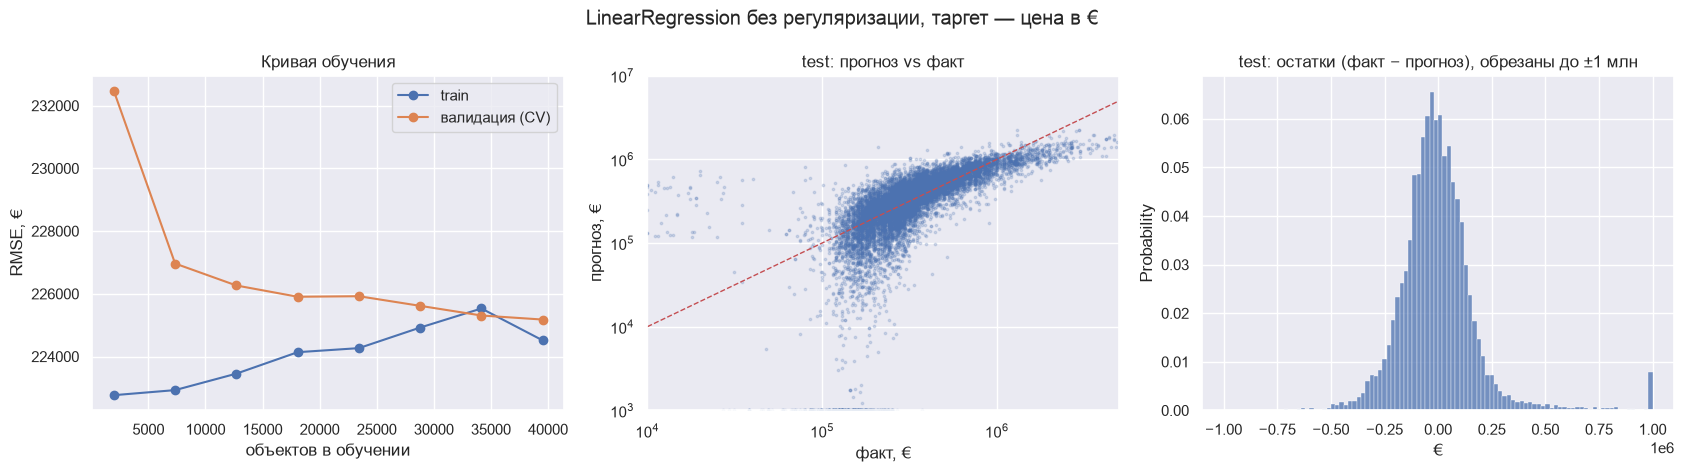

In [30]:
plot_fit(ols, 'LinearRegression без регуляризации, таргет — цена в €')

In [31]:
names = ols.named_steps['prep'].get_feature_names_out()
coef = pd.Series(ols.named_steps['model'].coef_, index=names)
print('Коэффициенты числовых признаков (€ за единицу признака):')
print(coef[coef.index.str.startswith('num__')].round(0))
print('\nСамые большие по модулю коэффициенты при категориях (€):')
print(coef[coef.index.str.startswith('cat__')].sort_values().iloc[[0, 1, 2, 3, -4, -3, -2, -1]].round(0))

Коэффициенты числовых признаков (€ за единицу признака):
num__LivingArea                             3148.0
num__NumberOfBathrooms                     72027.0
num__ConstructionYear                       1855.0
num__Parking                                4119.0
num__Elevator                               6396.0
num__missingindicator_NumberOfBathrooms    41912.0
num__missingindicator_ConstructionYear     40659.0
dtype: float64

Самые большие по модулю коэффициенты при категориях (€):
cat__City_Elvas             -260002.0
cat__City_Vieira do Minho   -224524.0
cat__City_Ponte de Sor      -143397.0
cat__City_Felgueiras        -138344.0
cat__City_Loulé              234275.0
cat__City_Lisboa             411744.0
cat__City_Castro Marim       413550.0
cat__City_Cascais            467975.0
dtype: float64


**Вывод.** TODO_22

### 2.3. Линейная регрессия с регуляризацией (Ridge), удалением выбросов и нормированием

**Что меняю и почему.**

1. **Логарифм таргета.** Из вопросов 6–7: цена сильно скошена вправо, а log(цены) почти симметричен.
   Модель на log(цены) предсказывает *относительные* эффекты (округ Лиссабон — «+X%», а не «+X €» для любой квартиры) — это ближе к тому, как устроены цены.
   Для метрик прогноз переводится обратно в евро (`TransformedTargetRegressor`), поэтому метрики сравнимы с 2.2.
2. **Логарифм площади.** Связь цена–площадь линейна в log-log масштабе (вопросы 5–6): log(цена) = a + b·log(площадь).
3. **Удаление выбросов — правило Тьюки (1.5·IQR) по log(цены м²).**
   - Почему не 3σ / z-score: они предполагают нормальность, а тесты в вопросе 7 её отвергли; квартили устойчивы к самим выбросам.
   - Почему по цене **за м²**, а не по цене: дорогая большая квартира — не выброс; выброс — это цена, не согласующаяся с площадью (перепутали площадь/цену, «доля в квартире», объявление-приманка).
   - Выбросы удаляются **только при обучении** (`FunctionSampler` из imbalanced-learn внутри Pipeline): в тесте удалять объекты нельзя — модель должна дать прогноз для любого объявления, поэтому test оцениваю целиком.
   - Порог считается внутри каждого фолда по его обучающей части — никакой утечки из валидации.
4. **Нормирование — `StandardScaler`.** L2-штраф Ridge `α·Σw²` зависит от масштаба признаков: без нормирования коэффициент при годе постройки (~2000) и при числе санузлов (~2) штрафовались бы несопоставимо.
   StandardScaler, а не MinMax: после логарифма и удаления выбросов признаки без экстремальных хвостов, а MinMax чувствителен к единичным крайним значениям.
5. **Регуляризация — Ridge (L2)**, α подбираю по 5-фолдовой CV на train. Ridge, а не Lasso: признаков мало и все осмысленные, отбирать нечего; Ridge сглаживает коэффициенты при коррелирующих признаках (площадь ↔ санузлы) и редких one-hot категориях.

In [32]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn import FunctionSampler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV

def drop_outliers_iqr(X, y, k=1.5):
    """y здесь уже log(цены) — TransformedTargetRegressor логарифмирует таргет до пайплайна."""
    log_ppm = y - np.log(X['LivingArea'].to_numpy())  # log(цена за м²)
    q1, q3 = np.percentile(log_ppm, [25, 75])
    keep = (log_ppm >= q1 - k * (q3 - q1)) & (log_ppm <= q3 + k * (q3 - q1))
    return X[keep], y[keep]

def make_ridge(alpha=1.0):
    pipe = ImbPipeline([
        ('outliers', FunctionSampler(func=drop_outliers_iqr, validate=False)),
        ('prep', make_preprocessor(scale=True, log_area=True)),
        ('model', Ridge(alpha=alpha)),
    ])
    return TransformedTargetRegressor(regressor=pipe, func=np.log, inverse_func=np.exp)

# сколько объектов отсеивает правило на всём train (для иллюстрации)
_Xk, _yk = drop_outliers_iqr(X_train, np.log(y_train))
print(f'выбросов по 1.5·IQR на train: {len(X_train) - len(_Xk)} из {len(X_train)} ({(1 - len(_Xk) / len(X_train)) * 100:.1f}%)')

выбросов по 1.5·IQR на train: 592 из 49416 (1.2%)


лучший alpha = 0.01, CV RMSE = 203,417 €


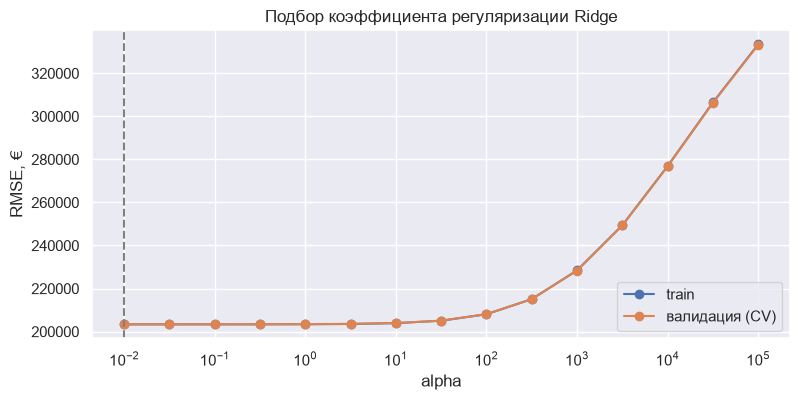

In [33]:
alphas = np.logspace(-2, 5, 15)
search = GridSearchCV(make_ridge(), {'regressor__model__alpha': alphas}, cv=cv,
                      scoring='neg_root_mean_squared_error', return_train_score=True)
search.fit(X_train, y_train)
best_alpha = search.best_params_['regressor__model__alpha']
print(f'лучший alpha = {best_alpha:.3g}, CV RMSE = {-search.best_score_:,.0f} €')

plt.figure(figsize=(9, 4))
plt.semilogx(alphas, -search.cv_results_['mean_train_score'], 'o-', label='train')
plt.semilogx(alphas, -search.cv_results_['mean_test_score'], 'o-', label='валидация (CV)')
plt.axvline(best_alpha, color='gray', ls='--')
plt.title('Подбор коэффициента регуляризации Ridge')
plt.xlabel('alpha')
plt.ylabel('RMSE, €')
plt.legend()
plt.show()

In [34]:
ridge = make_ridge(best_alpha)
res_ridge = evaluate(ridge, f'Ridge(alpha={best_alpha:.3g})')
res_ridge.round({'RMSE': 0, 'MAE': 0, 'R2': 3})

,RMSE,MAE,R2
Ridge(alpha=0.01),,,
train,203297.0,94920.0,0.679
"CV (5 фолдов, среднее)",203417.0,95290.0,0.678
test,213663.0,98025.0,0.669


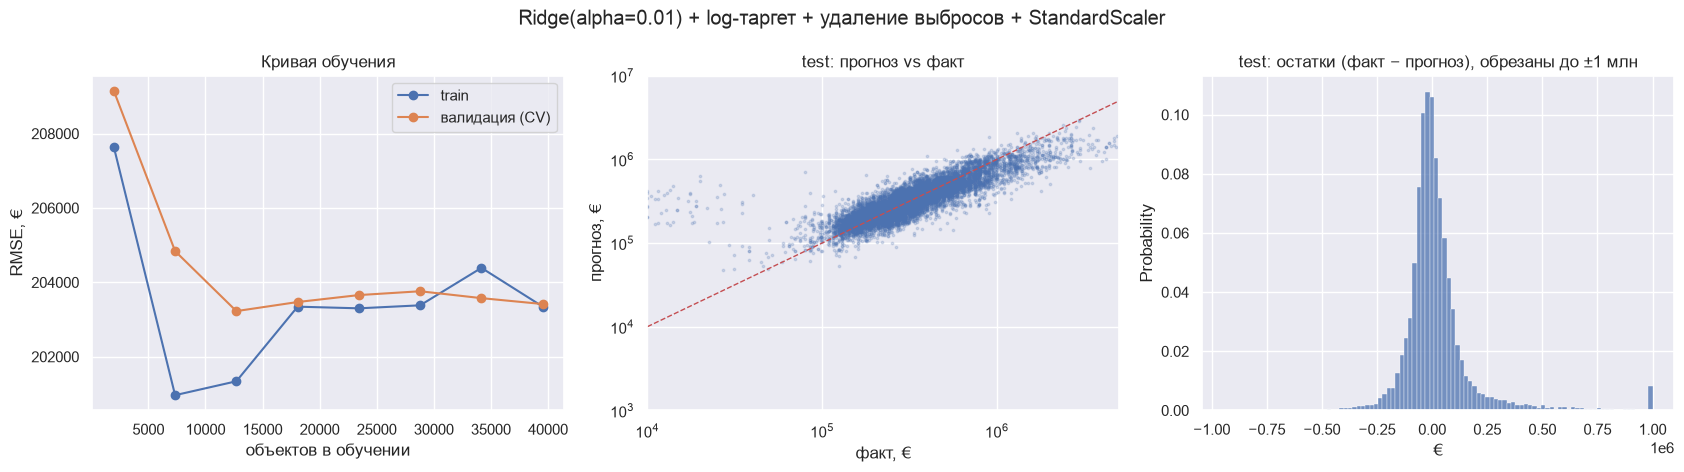

In [35]:
plot_fit(ridge, f'Ridge(alpha={best_alpha:.3g}) + log-таргет + удаление выбросов + StandardScaler')

In [36]:
inner = ridge.regressor_
names = inner.named_steps['prep'].get_feature_names_out()
coef = pd.Series(inner.named_steps['model'].coef_, index=names)
effect = (np.exp(coef) - 1) * 100  # модель в логарифмах: коэффициент ≈ % изменения цены
print('Числовые признаки (после стандартизации): изменение цены в % при +1 std признака')
print(effect[effect.index.str.startswith('num__')].round(1))
top = effect[effect.index.str.startswith('cat__')].sort_values()
print('\nКатегории: % к цене относительно «средней» категории (крайние значения)')
print(pd.concat([top.head(4), top.tail(4)]).round(1))

Числовые признаки (после стандартизации): изменение цены в % при +1 std признака
num__LivingArea                            25.8
num__NumberOfBathrooms                     11.1
num__ConstructionYear                       5.8
num__Parking                                0.7
num__Elevator                               3.4
num__missingindicator_NumberOfBathrooms     0.0
num__missingindicator_ConstructionYear      4.0
dtype: float64

Категории: % к цене относительно «средней» категории (крайние значения)
cat__City_Vieira do Minho     -38.1
cat__District_Portalegre      -32.5
cat__City_Castelo de Paiva    -30.3
cat__City_Valença             -30.1
cat__City_Castro Marim         72.8
cat__City_Odemira              76.1
cat__City_Cascais              88.8
cat__City_Lisboa              102.1
dtype: float64


#### Сравнение моделей на отложенной выборке

In [37]:
def log_metrics(model):
    p = model.predict(X_test)
    return {'RMSE log': root_mean_squared_error(np.log(y_test), np.log(np.clip(p, 1e3, None))),
            'MAPE-медиана, %': np.median(np.abs(p - y_test) / y_test) * 100}

cmp = pd.DataFrame({
    'LinearRegression': {**res_ols.loc['test'].to_dict(), **log_metrics(ols)},
    f'Ridge (alpha={best_alpha:.3g})': {**res_ridge.loc['test'].to_dict(), **log_metrics(ridge)},
}).T
print('отрицательных прогнозов цены у LinearRegression:', int((ols.predict(X_test) <= 0).sum()))
cmp.round({'RMSE': 0, 'MAE': 0, 'R2': 3, 'RMSE log': 3, 'MAPE-медиана, %': 1})

отрицательных прогнозов цены у LinearRegression: 308


,RMSE,MAE,R2,RMSE log,"MAPE-медиана, %"
LinearRegression,228063.0,129621.0,0.623,0.951,27.0
Ridge (alpha=0.01),213663.0,98025.0,0.669,0.339,17.9


**Выводы.** TODO_23

<font color='MediumSeaGreen'>**Задание 3 [баллов: 2] - бонусные баллы:**</font>

По итогам лекции №1 ответьте на вопросы о месте искусственного интеллекта среди инноваций в крупной компании (пример "Норильского никеля" - см видео в группе в ТГ).

1.Какие задачи моделирования и управления решаются?

2.Какие разделы/формальные задачи ИИ задействованы?

3.Какие физико-химические признаки для них используются?

4.Укажите (предположите) для нескольких признаков: числовые или категориальные, временная и пространственная дискретность регистрации, сырой признак или агрегат по нескольким, сильно зашумленный, много ли пропусков, особенности закона распределения, потенциал для data leakage


TODO_3

<font color='MediumSeaGreen'>**Задание 4 [баллов: 3] - бонусные баллы:**</font>

Покажите, что из максимизации правдоподобия выборки невязок, распределенных по нормальному закону, следует задача минимизации ошибки MSE, вычисленной по этим невязкам.

Обоснование принесет вам 2 балла.
Если выполните не на листе бумаги, а заполните ячейку (математические символы), то получите ещё 1 балл. Пример текста с математикой ниже

<font color='MediumSeaGreen'>***Пример текста***</font>

Из курса математического анализы мы знаем, что тригонометрические функции можно также применять к матрицам. Чтобы найти $sin(X)$, где $X \in \mathbb{R}^{n\times n}$ – матрица с $n$ строками и $n$ столбцами, достаточно разложить функцию синус в ряд Тейлора:

$sin(x) = \sum_{i=1}^{\infty} a_i(x) = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \frac{x^7}{7!}+\dots$

И вместо $x$ подставить матрицу $X$:

$sin(X) = X - \frac{X^3}{3!} + \frac{X^5}{5!} - \frac{X^7}{7!}+\dots$

Тогда $sin(X)$ – тоже матрица!

Ограничимся 15 степенью, то есть:
$sin(X) \approx X - \frac{X^3}{3!} + \frac{X^5}{5!} - \frac{X^7}{7!}+ \dots - \frac{X^{15}}{15!}$

TODO_4